# 先行研究3：長距離相関による normal / super-diffusive transition

このノートブックでは、Hod and Keshet, *Phase-Transition in Binary Sequences with Long-Range Correlationsを出発点として、Merton型Poisson–lognormal強度モデルに同じ分散スケーリングの見方を接続する。

中心的に観察する量は、累積量の分散を系列長で割った **scaled variance** $D(L)/L$ である。通常拡散では定数に収束し、super-diffusionでは発散する。

In [1]:
import sys

print(sys.executable)

c:\Users\h20s1\workspace\.venv\Scripts\python.exe


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 2.4.2
matplotlib: 3.10.8


## 1. 出発点：履歴依存二値系列 


### 記号

| 記号 | 定義 |
|---|---|
| $a_i\in\{0,1\}$ | 系列の第 $i$ 要素 |
| $L$ | 現在までの系列長 |
| $k$ | 最初の $L$ 要素に含まれる 1 の個数 |
| $x=2k-L$ | 1 を $+1$、0 を $-1$ とみなしたランダムウォークの位置 |
| $\mu\in(-1,1)$ | 履歴への追随度。$\mu>0$ は persistence、$\mu<0$ は anti-persistence |
| $L_0>0$ | 相関が効き始めるまでの過渡スケール |
| $P(x,L)$ | 長さ $L$ で位置 $x$ にいる確率 |
| $D_{\mathrm{bin}}(L)=\operatorname{Var}(x_L)$ | 二値系列に対応する位置の分散 |

次の要素が 1 になる条件付き確率は
$$
p(k,L)=\frac12\left(1-\mu\frac{L-2k}{L+L_0}\right)
      =\frac12\left(1+\mu\frac{x}{L+L_0}\right).
$$
$\mu>0$ では過去に多かった記号が次にも現れやすくなり、正の長距離相関が生じる。連続極限では $P(x,L)$ は分散 $D_{\mathrm{bin}}(L)$ のガウス分布となり、$\mu\ne1/2$ では
$$
D_{\mathrm{bin}}(L;\mu,L_0)
=\frac{L+L_0}{1-2\mu}
\left[1-\left(\frac{L_0}{L+L_0}\right)^{1-2\mu}\right],
$$
$\mu_c=1/2$ では
$$
D_{\mathrm{bin}}(L;\mu_c,L_0)
=(L+L_0)\log\left(\frac{L+L_0}{L_0}\right).
$$
したがって $L\gg L_0$ で
$$
\frac{D_{\mathrm{bin}}(L)}{L}\sim
\begin{cases}
\text{constant}, & \mu<1/2,\\
\log(L/L_0), & \mu=1/2,\\
L^{2\mu-1}, & \mu>1/2.
\end{cases}
$$
ここで $D_{\mathrm{bin}}(L)/L$ が定数なら normal diffusion、発散すれば super-diffusion と判定する。

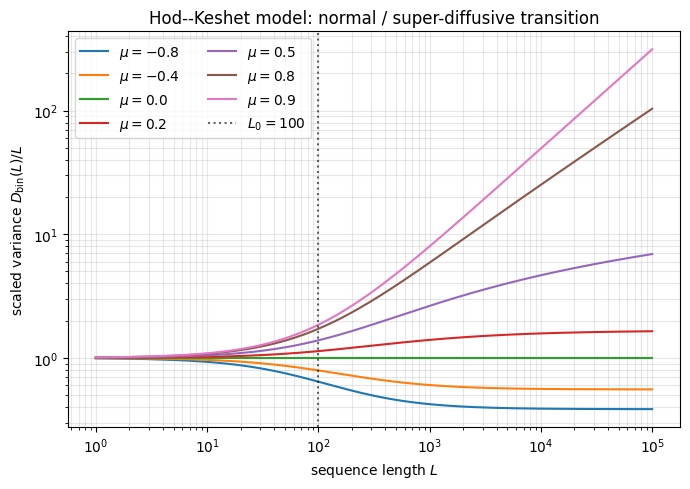

In [3]:
def binary_variance(L, mu, L0=100.0):
    """Hod--Keshet model, Eqs. (5) and (6)."""
    L = np.asarray(L, dtype=float)
    if np.isclose(mu, 0.5):
        return (L + L0) * np.log((L + L0) / L0)

    exponent = 1.0 - 2.0 * mu
    return (L + L0) / exponent * (1.0 - (L0 / (L + L0)) ** exponent)


L0 = 100.0
L_grid = np.unique(np.logspace(0, 5, 400).astype(int))
mu_list = [-0.8, -0.4, 0.0, 0.2, 0.5, 0.8, 0.9]

plt.figure(figsize=(7, 5))
for mu in mu_list:
    D_bin = binary_variance(L_grid, mu=mu, L0=L0)
    plt.loglog(L_grid, D_bin / L_grid, label=rf"$\mu={mu}$")

plt.axvline(L0, color="black", linestyle=":", alpha=0.6, label=rf"$L_0={L0:g}$")
plt.xlabel(r"sequence length $L$")
plt.ylabel(r"scaled variance $D_{\mathrm{bin}}(L)/L$")
plt.title("Hod--Keshet model: normal / super-diffusive transition")
plt.grid(True, which="both", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## 2. Merton型モデルへの接続：潜在変数の自己相関

Merton型Poisson–lognormalモデルでは、二値系列を直接生成する代わりに、標準ガウス潜在変数 $y_t$ に時間相関を与え、強度を $\lambda_t=\lambda_0\exp(\alpha y_t)$ とする。以下の $h$ は離散時間のラグである。

### 指数減衰（short memory）
$$
k(x, x') = \sigma^2 \exp\left(-\frac{|x - x'|}{\ell}\right)
$$

$y_t$ の自己相関は、時間刻みを $\Delta x$ とすると
$$
d_h=\operatorname{Corr}(y_t,y_{t+h})=\theta^h,
\qquad \theta=\exp(-\Delta x/\ell).
$$

### べき乗減衰（long / intermediate memory）
$$
k(x, x') = \frac{\sigma^2}{(1 + |x - x'|)^{\gamma}}
$$
離散時間点 $x=t$ では
$$
d_h=\operatorname{Corr}(y_t,y_{t+h})=(1+h)^{-\gamma}.
$$
$\sum_{h\ge1}d_h$ は $\gamma>1$ で収束し、$\gamma\le1$ で発散する。この可和性の境界 $\gamma_c=1$ が、後で見る分散スケーリングの転移点になる。

In [4]:
def _pairwise_dist(X1, X2):
    return np.abs(X1 - X2.T)


def kernel_exponential(X1, X2, sigma=1.0, ell=1.0):
    dist = _pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-dist / ell)


def kernel_power_law_like(X1, X2, sigma=1.0, gamma=0.7):
    dist = _pairwise_dist(X1, X2)
    return sigma**2 / ((1 + dist) ** gamma)

In [5]:
def sample_gp(K, mean=None, n_samples=5, jitter=1e-6):
    n = K.shape[0]  # size kernel
    K_stable = K + jitter * np.eye(n)  # positive definite
    if mean is None:
        mean = np.zeros(n)
    return np.random.multivariate_normal(mean, K_stable, size=n_samples)

In [6]:
def sample_acf(series, max_lag=30):
    x = np.asarray(series, dtype=float)
    x = x - np.mean(x)
    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(max_lag + 1)

    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acf_vals.append(num / denom)

    return np.array(acf_vals)


def plot_kernel_samples_and_acf(x, K, samples, title, max_lag=30, theoretical_acf=None):
    max_lag = int(max_lag)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. covariance matrix
    im = axes[0].imshow(K, origin="upper", aspect="auto")
    axes[0].set_title(f"{title} covariance")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # 2. prior samples
    for i in range(samples.shape[0]):
        if i >= 3:
            break
        axes[1].plot(x.ravel(), samples[i], lw=1.5)
    axes[1].set_title(f"{title} prior samples")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("f(x)")
    axes[1].grid(True, alpha=0.3)

    # 3. sample ACF across simulated paths
    acf_list = []
    for s in samples:
        acf_s = sample_acf(s, max_lag=max_lag)
        acf_list.append(acf_s)

    acf_array = np.array(acf_list)

    acf_mean = acf_array.mean(axis=0)
    acf_std = acf_array.std(axis=0)

    lags = np.arange(max_lag + 1)

    axes[2].plot(lags, acf_mean, label="mean ACF")
    axes[2].fill_between(
        lags, acf_mean - acf_std, acf_mean + acf_std, alpha=0.3, label="±1 std"
    )
    if theoretical_acf is not None:
        axes[2].plot(
            lags, theoretical_acf(lags), linestyle="--", label="theoretical ACF"
        )

    axes[2].axhline(0.0, color="black", lw=1)
    axes[2].set_title(f"{title} sample ACF (mean ± std)")
    axes[2].set_xlabel("lag")
    axes[2].set_ylabel("ACF")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

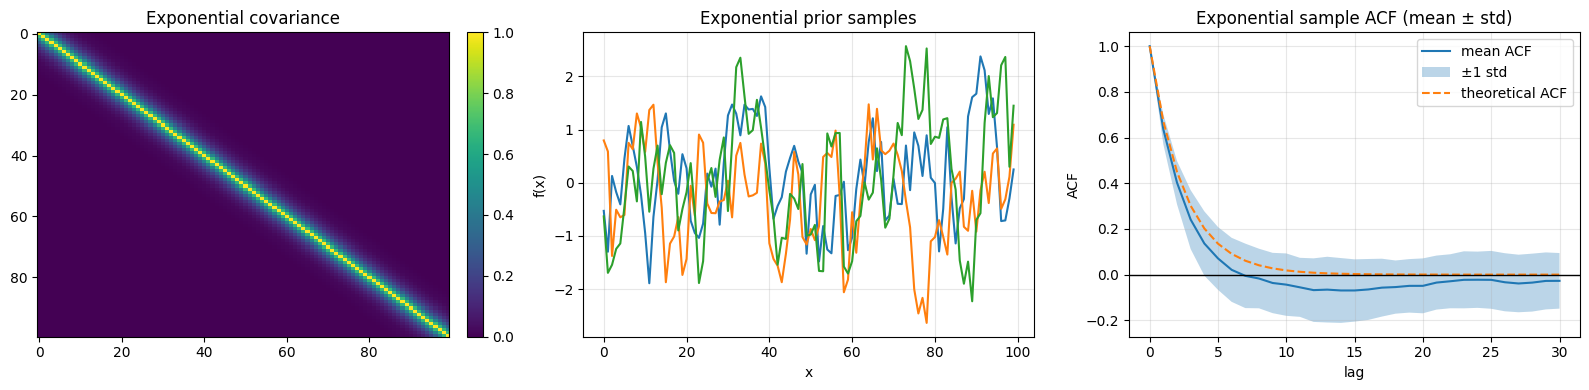

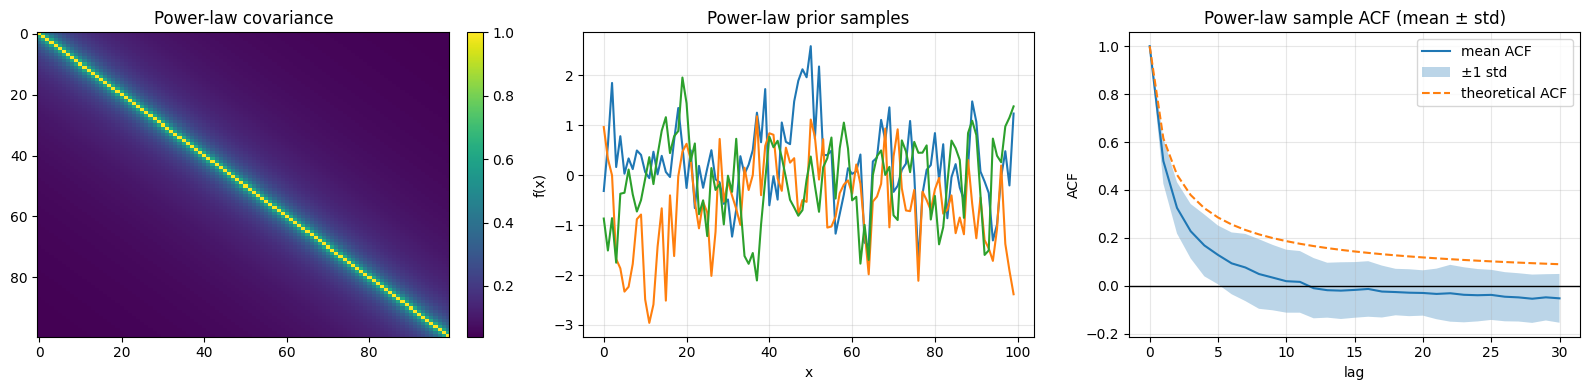

In [7]:
np.random.seed(42)
x = np.arange(100, dtype=float)[:, None]  # discrete time t = 0, ..., 99
ell_demo = 2.5
gamma_demo = 0.7

kernel_specs = {
    "Exponential": (
        kernel_exponential(x, x, sigma=1.0, ell=ell_demo),
        lambda h: np.exp(-h / ell_demo),
    ),
    "Power-law": (
        kernel_power_law_like(x, x, sigma=1.0, gamma=gamma_demo),
        lambda h: (1.0 + h) ** (-gamma_demo),
    ),
}

for name, (K, theoretical_acf) in kernel_specs.items():
    samples = sample_gp(K, n_samples=100, jitter=1e-6)
    plot_kernel_samples_and_acf(
        x, K, samples, name, max_lag=30, theoretical_acf=theoretical_acf
    )

## 3. 強度累積和の scaled variance と `1-16.pdf` の対応

二つのモデルで同じ記号を流用すると混乱しやすいため、ここからは分散を明示的に区別する。

| 記号 | 定義 |
|---|---|
| $D_{\mathrm{bin}}(L)=\operatorname{Var}(x_L)$ | `1-16.pdf` の二値系列に対応する位置の分散 |
| $y_t$ | 平均 0、分散 1 の定常ガウス潜在変数 |
| $d_h=\operatorname{Corr}(y_t,y_{t+h})$ | 潜在変数のラグ $h$ 自己相関 |
| $\lambda_0>0$ | 強度の基準水準 |
| $\alpha$ | 潜在変数が強度へ及ぼす大きさ |
| $\lambda_t=\lambda_0\exp(\alpha y_t)$ | 時点 $t$ のランダム強度 |
| $S_T=\sum_{t=1}^{T}\lambda_t$ | $T$ 時点までの累積強度 |
| $D_\lambda(T)=\operatorname{Var}(S_T)$ | 累積強度の分散 |
| $\bar V=\operatorname{Var}(\lambda_t)$ | 1 時点の強度の分散 |
| $\rho_\lambda(h)=\operatorname{Corr}(\lambda_t,\lambda_{t+h})$ | 強度系列の自己相関 |
| $Q_\lambda(T)=D_\lambda(T)/(T\bar V)$ | 無次元化した scaled variance |

$y_t$ が標準ガウスなら、対数正規分布のモーメントから
$$
\bar V
=\lambda_0^2 e^{\alpha^2}\left(e^{\alpha^2}-1\right),
\qquad
\rho_\lambda(h)
=\frac{e^{\alpha^2d_h}-1}{e^{\alpha^2}-1}.
$$
したがって、定常系列の共分散和の恒等式より
$$
D_\lambda(T)
=\bar V\left[T+2\sum_{h=1}^{T-1}(T-h)\rho_\lambda(h)\right],
$$
$$
Q_\lambda(T)
=1+2\sum_{h=1}^{T-1}\left(1-\frac{h}{T}\right)\rho_\lambda(h).
$$
ここで重要なのは、一般の $\alpha$ では潜在相関 $d_h$ と強度相関 $\rho_\lambda(h)$ は同一ではないことである。ただし $d_h\to0$ では $\rho_\lambda(h)\sim C_\alpha d_h$ なので、長いラグでの減衰指数は保存される。

$d_h\sim h^{-\gamma}$ のとき、漸近的には
$$
Q_\lambda(T)\sim
\begin{cases}
\text{constant}, & \gamma>1,\\
\log T, & \gamma=1,\\
T^{1-\gamma}, & 0<\gamma<1.
\end{cases}
$$
指数減衰では相関和が収束するため、$Q_\lambda(T)$ は定数に収束する。

### 相転移の対応

`1-16.pdf` の super-diffusive 側では $D_{\mathrm{bin}}(L)/L\sim L^{2\mu-1}$、Merton 型モデルでは $Q_\lambda(T)\sim T^{1-\gamma}$ である。したがって、**発散指数だけ**を対応させると
$$
2\mu-1=1-\gamma,
\qquad \gamma=2(1-\mu),
$$
となり、臨界点は $\mu_c=1/2\leftrightarrow\gamma_c=1$ に対応する。

ただし、これは分散スケーリングによる分類の対応であり、二つのモデルの生成機構や確率分布が同一という意味ではない。

> **Merton 論文 Fig. 2 との違い**：標本平均 $\bar\lambda_T=S_T/T$ の分散は $\operatorname{Var}(\bar\lambda_T)/\bar V=Q_\lambda(T)/T$ である。ここで描く $Q_\lambda(T)$ は、`1-16.pdf` の $D(L)/L$ と直接比較するための量である。

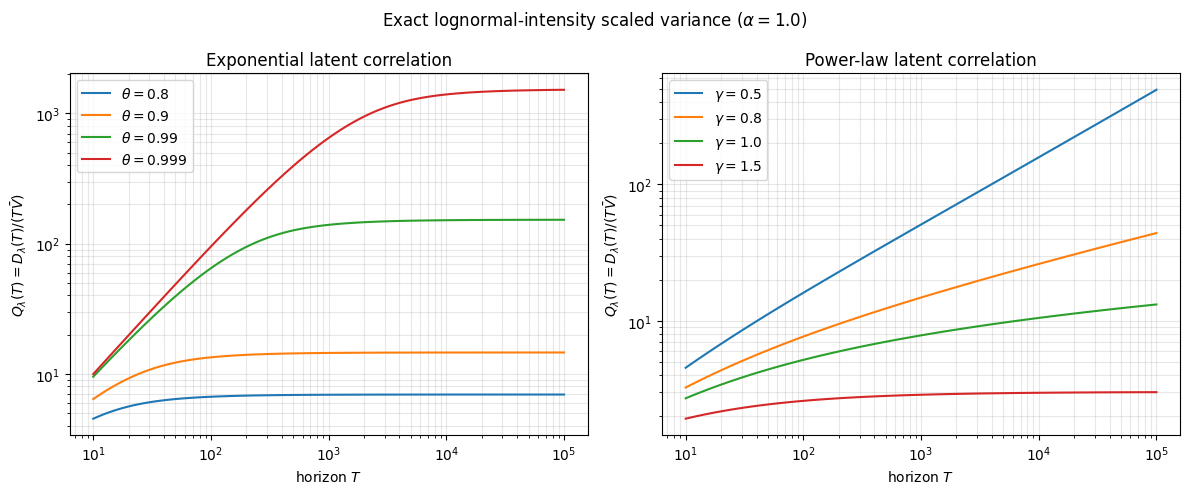

In [8]:
def intensity_acf_from_latent(latent_acf, alpha=1.0):
    # 標準ガウス潜在変数の ACF を対数正規強度の ACF に変換する。
    latent_acf = np.asarray(latent_acf, dtype=float)
    if np.isclose(alpha, 0.0):
        # alpha -> 0 の極限。alpha=0 そのものでは強度分散は 0 になる。
        return latent_acf
    return np.expm1(alpha**2 * latent_acf) / np.expm1(alpha**2)


def normalized_cumulative_variance(T, latent_acf_values, alpha=1.0):
    # Z_T = D_lambda(T) / Vbar を共分散和から計算する。
    T = int(T)
    h = np.arange(1, T, dtype=float)
    latent_acf_values = np.asarray(latent_acf_values, dtype=float)
    if latent_acf_values.shape != h.shape:
        raise ValueError("latent_acf_values must contain lags 1, ..., T-1")
    rho_lambda = intensity_acf_from_latent(latent_acf_values, alpha=alpha)
    return T + 2.0 * np.sum((T - h) * rho_lambda)


def z_exp(T, theta, alpha=1.0):
    h = np.arange(1, int(T), dtype=float)
    return normalized_cumulative_variance(T, theta**h, alpha=alpha)


def z_pow(T, gamma, alpha=1.0):
    h = np.arange(1, int(T), dtype=float)
    return normalized_cumulative_variance(T, (1.0 + h) ** (-gamma), alpha=alpha)


T_grid = np.unique(np.logspace(1, 5, 100).astype(int))
theta_list = [0.8, 0.9, 0.99, 0.999]
gamma_list = [0.5, 0.8, 1.0, 1.5]
alpha_theory = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for theta in theta_list:
    q_values = np.array([z_exp(T, theta, alpha=alpha_theory) / T for T in T_grid])
    axes[0].loglog(T_grid, q_values, label=rf"$\theta={theta}$")
axes[0].set_title("Exponential latent correlation")
axes[0].set_xlabel(r"horizon $T$")
axes[0].set_ylabel(r"$Q_\lambda(T)=D_\lambda(T)/(T\bar V)$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

for gamma in gamma_list:
    q_values = np.array([z_pow(T, gamma, alpha=alpha_theory) / T for T in T_grid])
    axes[1].loglog(T_grid, q_values, label=rf"$\gamma={gamma}$")
axes[1].set_title("Power-law latent correlation")
axes[1].set_xlabel(r"horizon $T$")
axes[1].set_ylabel(r"$Q_\lambda(T)=D_\lambda(T)/(T\bar V)$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

fig.suptitle(rf"Exact lognormal-intensity scaled variance ($\alpha={alpha_theory}$)")
plt.tight_layout()
plt.show()

### 有限サイズで測る「超拡散の超過指数」

$Q_\lambda(T)$ の増え方を隣接する二つのスケールで測るため、
$$
\kappa_T
=\log_2\left(\frac{Q_\lambda(2T)}{Q_\lambda(T)}\right)
$$
を定義する。$Q_\lambda(T)\propto T^\kappa$ なら $\kappa_T=\kappa$ となるため、通常拡散からの超過分だけを直接読める。

べき乗相関 $d_h\sim h^{-\gamma}$ では
$$
\kappa_T\longrightarrow
\begin{cases}
1-\gamma, & 0<\gamma<1,\\
0, & \gamma>1.
\end{cases}
$$
$\gamma=1$ では $Q_\lambda(T)\sim\log T$ なので、発散は続くが $\kappa_T$ は非常にゆっくり 0 に近づく。`1-16.pdf` 側で同じ指標を作ると、臨界点の対数補正を除いて $\max(2\mu-1,0)$ に対応する。

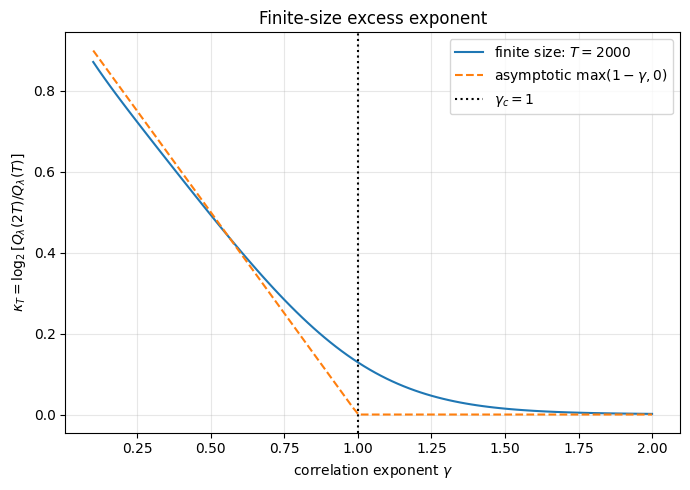

In [9]:
gamma_grid = np.linspace(0.1, 2.0, 100)
T0 = 2000

kappa_values = []
for gamma in gamma_grid:
    q_T = z_pow(T0, gamma, alpha=alpha_theory) / T0
    q_2T = z_pow(2 * T0, gamma, alpha=alpha_theory) / (2 * T0)
    kappa_values.append(np.log2(q_2T / q_T))
kappa_values = np.asarray(kappa_values)

plt.figure(figsize=(7, 5))
plt.plot(gamma_grid, kappa_values, label=rf"finite size: $T={T0}$")
plt.plot(
    gamma_grid,
    np.maximum(1.0 - gamma_grid, 0.0),
    linestyle="--",
    label=r"asymptotic $\max(1-\gamma,0)$",
)
plt.axvline(1.0, color="black", linestyle=":", label=r"$\gamma_c=1$")
plt.xlabel(r"correlation exponent $\gamma$")
plt.ylabel(r"$\kappa_T=\log_2[Q_\lambda(2T)/Q_\lambda(T)]$")
plt.title("Finite-size excess exponent")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Monte Carlo による確認

独立な潜在変数経路を複数生成し、各経路を $\lambda_t=\lambda_0e^{\alpha y_t}$ に変換する。経路間で累積和 $S_T$ の標本分散を取り、理論値と同じ
$$
Q_\lambda(T)=\frac{\operatorname{Var}(S_T)}{T\bar V}
$$
を推定する。

以下は $100$ 経路だけの pilot simulation なので、長い $T$ では推定誤差が大きい。相転移の判定には上の解析式を主とし、Monte Carlo は実装確認として使う。

In [10]:
np.random.seed(42)
T_max = 1000
x = np.arange(T_max, dtype=float)[:, None]

In [11]:
def to_intensity(samples, lambda0=1.0, alpha=1.0):
    """潜在ガウス経路を対数正規強度へ変換する。"""
    return lambda0 * np.exp(alpha * samples)


def lognormal_intensity_variance(lambda0=1.0, alpha=1.0, latent_variance=1.0):
    """lambda0 * exp(alpha*y), y~N(0, latent_variance), の周辺分散。"""
    a2v = alpha**2 * latent_variance
    return lambda0**2 * np.exp(a2v) * np.expm1(a2v)


def cumulative_sum_variance(lam_samples):
    """独立経路間で D_lambda(T)=Var(sum_{t=1}^T lambda_t) を推定する。"""
    cumulative = np.cumsum(lam_samples, axis=1)
    D_values = np.var(cumulative, axis=0, ddof=1)
    T_values = np.arange(1, lam_samples.shape[1] + 1)
    return T_values, D_values


def scaled_variance_excess_exponent(D_values):
    """標本分散から kappa_T = log2(Q(2T)/Q(T)) を計算する。"""
    D_values = np.asarray(D_values, dtype=float)
    T_base = np.arange(1, len(D_values) // 2 + 1)
    q_T = D_values[T_base - 1] / T_base
    q_2T = D_values[2 * T_base - 1] / (2 * T_base)
    return T_base, np.log2(q_2T / q_T)

In [12]:
ell_mc = 1.0
gamma_mc = 0.7
n_paths = 100
lambda0 = 1.0
alpha = 1.0

ex_K = kernel_exponential(x, x, sigma=1.0, ell=ell_mc)
pow_K = kernel_power_law_like(x, x, sigma=1.0, gamma=gamma_mc)

ex_samples = sample_gp(ex_K, n_samples=n_paths, jitter=1e-6)
pow_samples = sample_gp(pow_K, n_samples=n_paths, jitter=1e-6)

ex_lambda = to_intensity(ex_samples, lambda0=lambda0, alpha=alpha)
pow_lambda = to_intensity(pow_samples, lambda0=lambda0, alpha=alpha)

T_ex, D_ex = cumulative_sum_variance(ex_lambda)
T_pow, D_pow = cumulative_sum_variance(pow_lambda)

Vbar_theory = lognormal_intensity_variance(lambda0=lambda0, alpha=alpha)
theta_mc = np.exp(-1.0 / ell_mc)

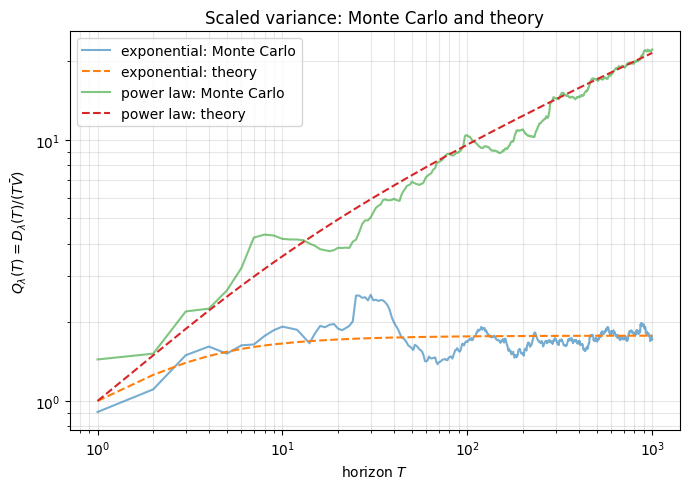

In [13]:
Q_ex_mc = D_ex / (T_ex * Vbar_theory)
Q_pow_mc = D_pow / (T_pow * Vbar_theory)

Q_ex_theory = np.array([z_exp(T, theta_mc, alpha=alpha) / T for T in T_ex])
Q_pow_theory = np.array([z_pow(T, gamma_mc, alpha=alpha) / T for T in T_pow])

plt.figure(figsize=(7, 5))
plt.loglog(T_ex, Q_ex_mc, alpha=0.6, label="exponential: Monte Carlo")
plt.loglog(T_ex, Q_ex_theory, linestyle="--", label="exponential: theory")
plt.loglog(T_pow, Q_pow_mc, alpha=0.6, label="power law: Monte Carlo")
plt.loglog(T_pow, Q_pow_theory, linestyle="--", label="power law: theory")
plt.xlabel(r"horizon $T$")
plt.ylabel(r"$Q_\lambda(T)=D_\lambda(T)/(T\bar V)$")
plt.title("Scaled variance: Monte Carlo and theory")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

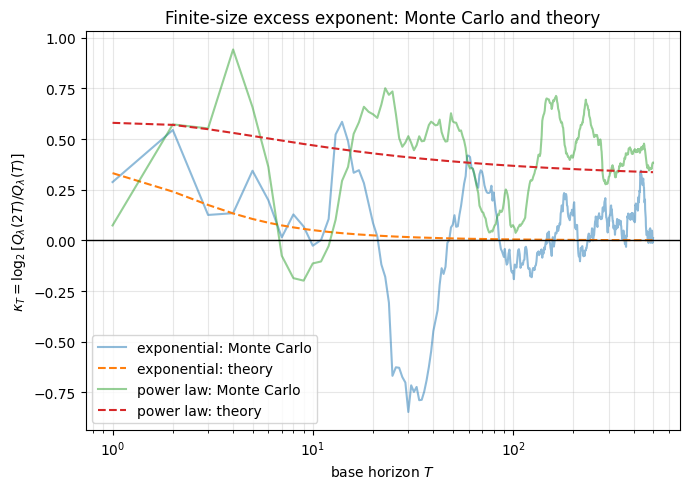

In [14]:
T_base_ex, kappa_ex_mc = scaled_variance_excess_exponent(D_ex)
T_base_pow, kappa_pow_mc = scaled_variance_excess_exponent(D_pow)


def theoretical_kappa(T_values, z_function, *args, **kwargs):
    values = []
    for T in T_values:
        q_T = z_function(T, *args, **kwargs) / T
        q_2T = z_function(2 * T, *args, **kwargs) / (2 * T)
        values.append(np.log2(q_2T / q_T))
    return np.asarray(values)


kappa_ex_theory = theoretical_kappa(T_base_ex, z_exp, theta_mc, alpha=alpha)
kappa_pow_theory = theoretical_kappa(T_base_pow, z_pow, gamma_mc, alpha=alpha)

plt.figure(figsize=(7, 5))
plt.semilogx(T_base_ex, kappa_ex_mc, alpha=0.5, label="exponential: Monte Carlo")
plt.semilogx(T_base_ex, kappa_ex_theory, linestyle="--", label="exponential: theory")
plt.semilogx(T_base_pow, kappa_pow_mc, alpha=0.5, label="power law: Monte Carlo")
plt.semilogx(T_base_pow, kappa_pow_theory, linestyle="--", label="power law: theory")
plt.axhline(0.0, color="black", linewidth=1)
plt.xlabel(r"base horizon $T$")
plt.ylabel(r"$\kappa_T=\log_2[Q_\lambda(2T)/Q_\lambda(T)]$")
plt.title("Finite-size excess exponent: Monte Carlo and theory")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 読み取り方

- $Q(T)$ が定数へ近づく：$D(T)\propto T$ の normal diffusion。
- $Q(T)$ が $\log T$ で増える：臨界点。有限標本では定数との区別が難しい。
- $Q(T)$ が $T^\kappa$（$\kappa>0$）で増える：$D(T)\propto T^{1+\kappa}$ の super-diffusion。
- 有限範囲では、相関長の長い指数減衰もべき乗減衰に似て見える。そのため、図だけでなく複数の $T$ 範囲での安定性やモデル比較も確認する。
- $Q(T)$ の発散は長距離依存と整合的だが、それだけで特定の生成機構を証明するものではない。